In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

DATA LOADING & BASIC CHECKS

In [82]:
# Load the dataset
df = pd.read_csv("employee_attrition_dataset_10000.csv")
print(f"Dataset Shape:{df.shape}")
print(f"Columns:{df.columns.tolist()}")


Dataset Shape:(10000, 26)
Columns:['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department', 'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked', 'Attrition']


In [83]:
# Basic Information
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

In [84]:
# Checking for Duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [85]:
# Check for Missing Values
missing = df.isnull().sum()
print(missing[missing>0] if missing.sum()>0 else "No Missing Values Found!")

No Missing Values Found!


In [86]:
# Target Variable Distribution
print(df.value_counts())


Employee_ID  Age  Gender  Marital_Status  Department  Job_Role   Job_Level  Monthly_Income  Hourly_Rate  Years_at_Company  Years_in_Current_Role  Years_Since_Last_Promotion  Work_Life_Balance  Job_Satisfaction  Performance_Rating  Training_Hours_Last_Year  Overtime  Project_Count  Average_Hours_Worked_Per_Week  Absenteeism  Work_Environment_Satisfaction  Relationship_with_Manager  Job_Involvement  Distance_From_Home  Number_of_Companies_Worked  Attrition
9984         54   Male    Married         HR          Analyst    5          17865           89           9                 6                      5                           2                  5                 4                   96                        No        5              54                             7            1                              3                          4                4                   2                           No           1
9983         48   Female  Married         Finance     Manager    4          1

In [87]:
# Summary Statistics for Numeric Columns
print(df.describe())

       Employee_ID           Age     Job_Level  Monthly_Income   Hourly_Rate  \
count  10000.00000  10000.000000  10000.000000    10000.000000  10000.000000   
mean    5000.50000     39.561800      2.990800    11436.716700     57.032300   
std     2886.89568     11.454986      1.410643     4926.528302     24.703261   
min        1.00000     20.000000      1.000000     3000.000000     15.000000   
25%     2500.75000     30.000000      2.000000     7182.500000     36.000000   
50%     5000.50000     40.000000      3.000000    11401.500000     57.000000   
75%     7500.25000     49.000000      4.000000    15679.500000     78.000000   
max    10000.00000     59.000000      5.000000    19999.000000     99.000000   

       Years_at_Company  Years_in_Current_Role  Years_Since_Last_Promotion  \
count      10000.000000           10000.000000                10000.000000   
mean          14.936200               7.451300                    4.471900   
std            8.431657               4.04290

VISUALIZATIONS

In [88]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

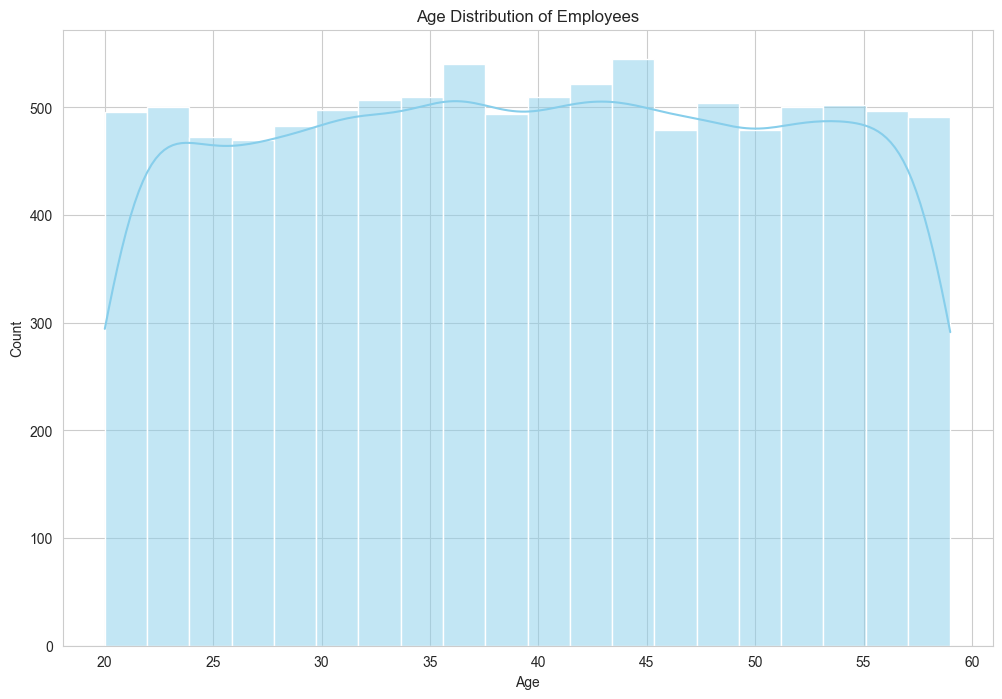

In [89]:
# Age Distribution
plt.figure()
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Employees')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig('age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

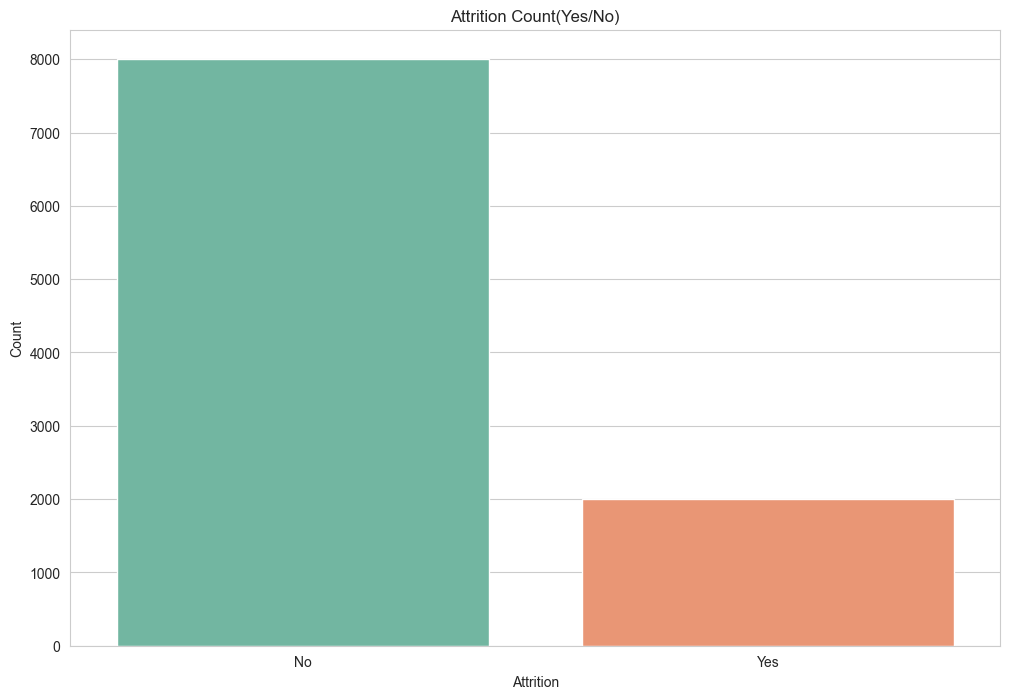

In [90]:
# Attrition Count (Target Variable)
plt.figure()
sns.countplot(x = "Attrition", data = df, palette = "Set2")
plt.title("Attrition Count(Yes/No)")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.savefig("Attrition_count.png", dpi=300, bbox_inches = "tight")
plt.show()


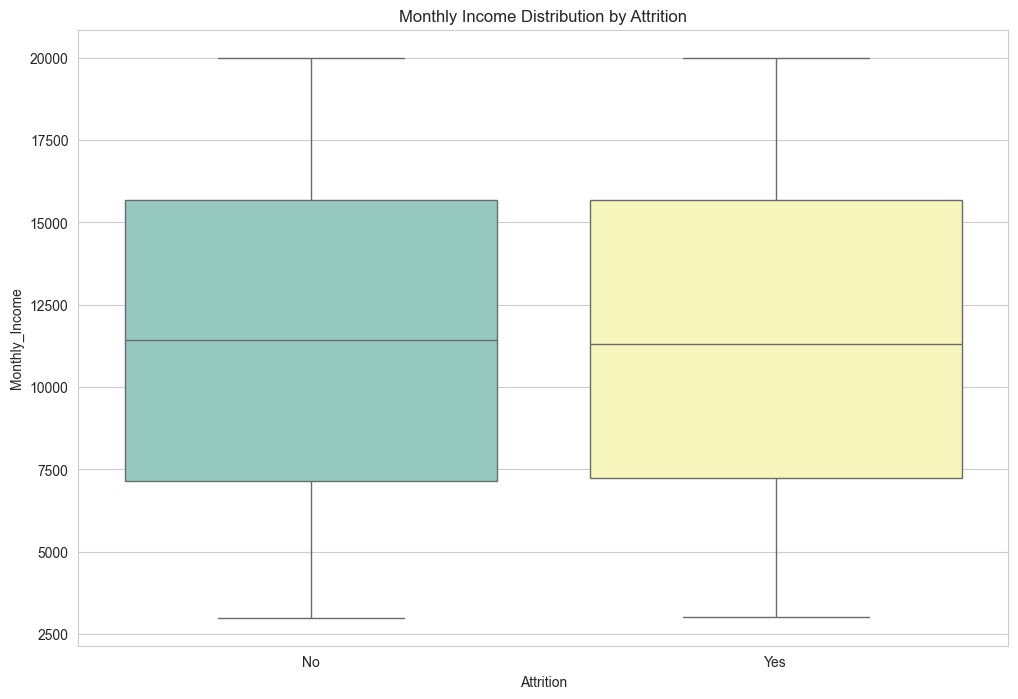

In [91]:
# Monthly Income Distribution
plt.figure()
sns.boxplot(x = "Attrition", y = "Monthly_Income", data = df, palette = "Set3")
plt.title("Monthly Income Distribution by Attrition")
plt.savefig("income_by_attrition.jpg", dpi=300, bbox_inches = "tight")
plt.show()

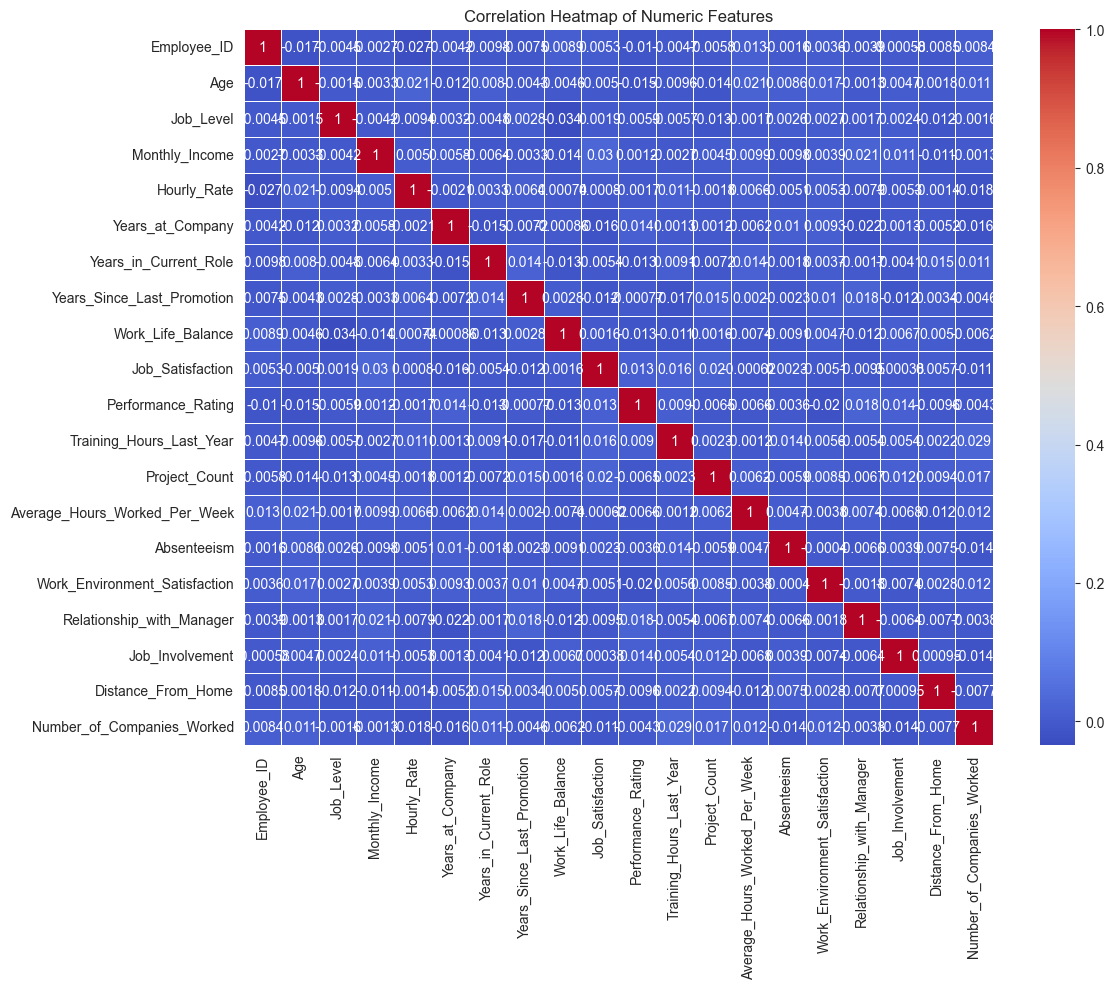

In [92]:
# Correlation Heatmap
plt.figure(figsize = (12,10))
numeric_df = df.select_dtypes(include =[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", linewidths = 0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.xticks (rotation = 90)
plt.yticks (rotation = 0)
plt.tight_layout()
plt.savefig("correlation heatmap.jpg", dpi=300, bbox_inches = "tight")
plt.show()

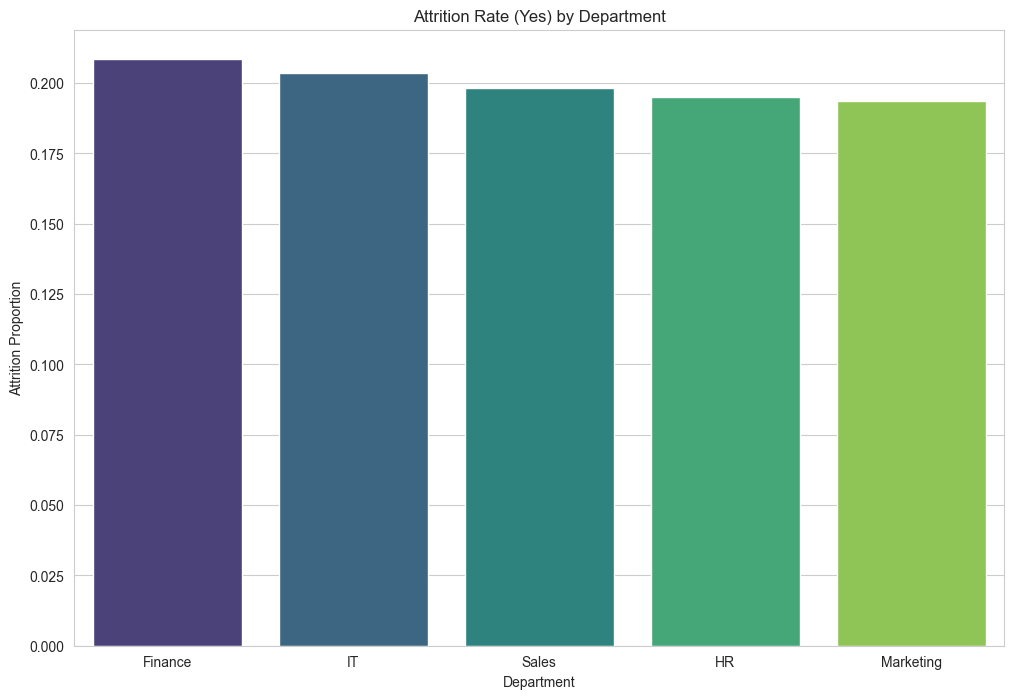

In [93]:
# Attrition Rate by Department
plt.figure()
attrition_by_dept = df.groupby("Department")["Attrition"].apply(lambda x:(x=="Yes").mean()).sort_values(ascending = False)
sns.barplot (x = attrition_by_dept.index, y = attrition_by_dept.values, palette = "viridis")
plt.title("Attrition Rate (Yes) by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Proportion")
plt.xticks(rotation = 0)
plt.savefig("attrition_by_dept.jpg", dpi = 300, bbox_inches = "tight")
plt.show()

<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

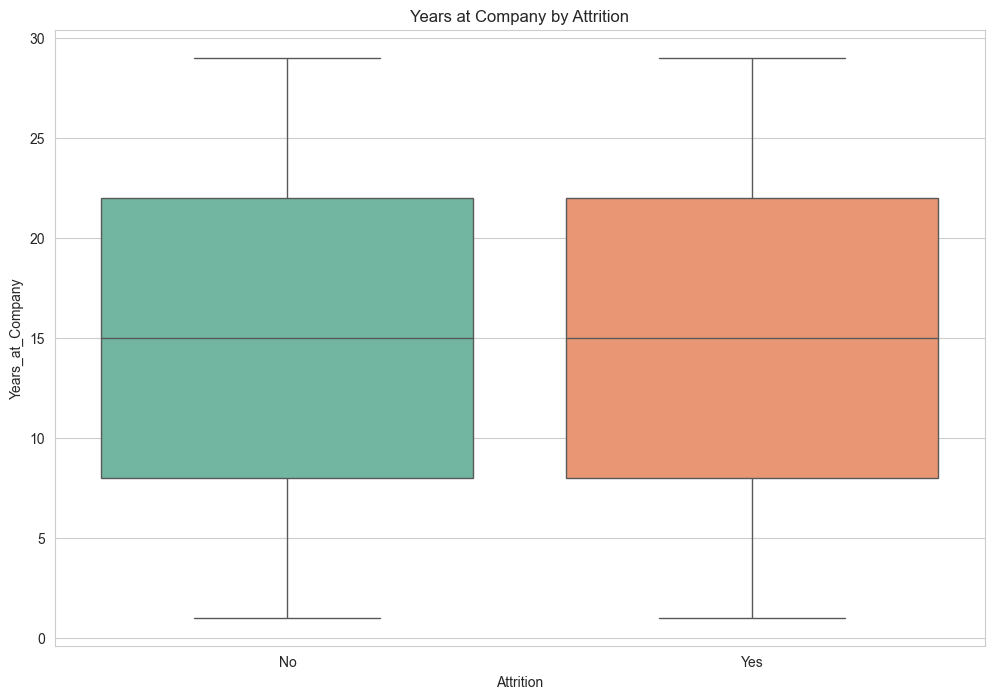

In [94]:
# Years at Compnay vs Attrition
plt.figure()
sns.boxplot(x = "Attrition", y = "Years_at_Company", data = df, palette = "Set2")
plt.title("Years at Company by Attrition")
plt.title

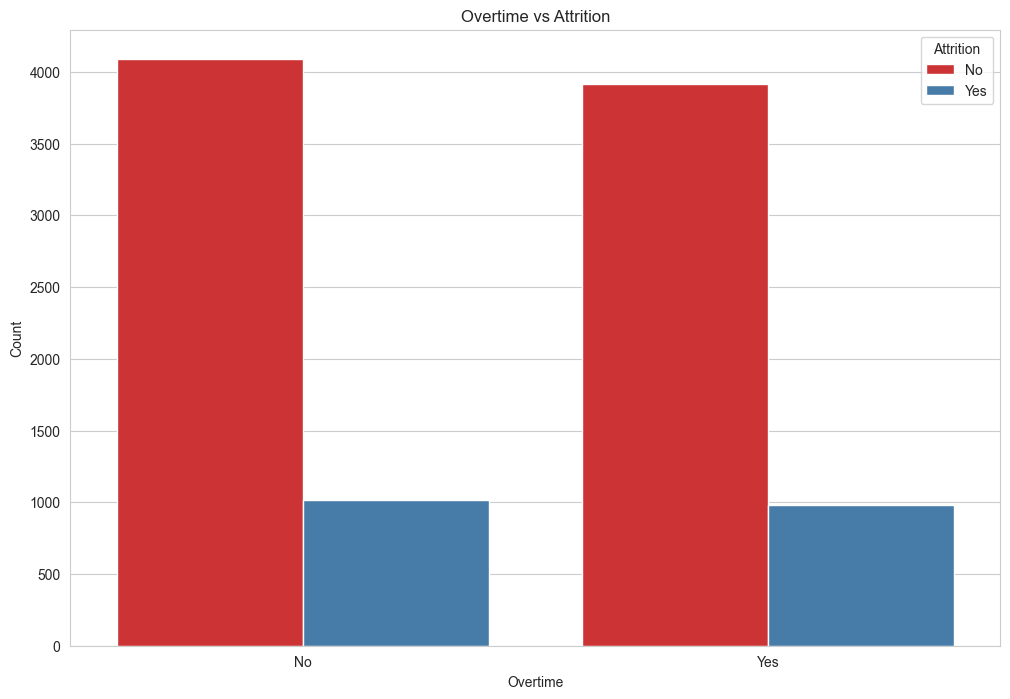

In [95]:
# Overtime vs Attrition
plt.figure()
sns.countplot(x = "Overtime", hue = "Attrition", data = df, palette = "Set1")
plt.title("Overtime vs Attrition")
plt.xlabel("Overtime")
plt.ylabel ("Count")
plt.savefig("Overtime_vs_Attrition.jpg", dpi = 300, bbox_inches = "tight")
plt.show()

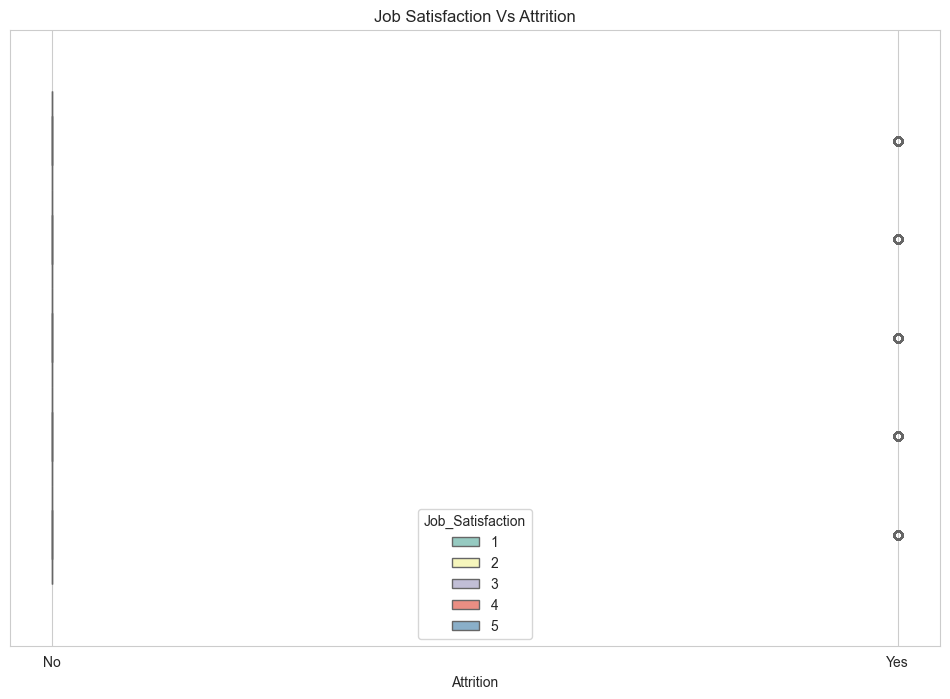

In [96]:
# Job Satisfaction vs Attrition
plt.figure()
sns.boxplot(x = "Attrition", hue = "Job_Satisfaction", data = df, palette = "Set3")
plt.title("Job Satisfaction Vs Attrition")
plt.savefig("job _satisfaction_vs_attrition.jpg", dpi = 300, bbox_inches = "tight")
plt.show()

Model Training Code

In [97]:
# Data processing
df = df.drop("Employee_ID", axis = 1)

In [98]:
# Encode categorical variables
le = LabelEncoder()
df["Attrition"] = le.fit_transform(df["Attrition"])
df["Attrition"]

0       0
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    0
9999    1
Name: Attrition, Length: 10000, dtype: int64

In [99]:
# Encode categorical features
for col in df.select_dtypes(include = "object").columns:
    if col != "Attrition":
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [103]:
df.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,58,1,2,0,3,5,7332,81,24,12,...,0,9,48,16,4,1,1,49,3,0
1,48,0,0,1,1,4,6069,55,18,7,...,1,9,57,10,4,1,1,25,1,0
2,34,0,1,3,3,4,11485,65,6,4,...,1,3,55,1,1,4,3,21,1,1
3,27,0,0,1,3,4,18707,28,12,9,...,0,9,53,2,3,4,1,46,2,0
4,40,1,1,1,0,1,16398,92,3,9,...,0,1,54,11,1,1,1,43,4,0


In [105]:
# Scale only features
numeric_cols = df.select_dtypes(include = ["int64", "float64"]).columns.drop("Attrition")
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [107]:
df.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1.609703,1.008436,1.232902,-1.426873,1.367537,1.424386,-0.833228,0.970273,1.075026,1.125164,...,-0.979608,1.556486,0.409523,1.144053,1.344401,-1.337524,-1.348971,1.668781,0.433979,0
1,0.736677,-0.991635,-1.224301,-0.721060,-0.423840,0.715454,-1.089608,-0.082273,0.363387,-0.111633,...,1.020817,1.556486,1.454670,0.102395,1.344401,-1.337524,-1.348971,-0.019130,-1.361549,0
2,-0.485560,-0.991635,0.004300,0.690568,1.367537,0.715454,0.009801,0.322552,-1.059892,-0.853711,...,1.020817,-0.769173,1.222415,-1.460092,-1.332089,1.352950,0.443205,-0.300448,-1.361549,1
3,-1.096678,-0.991635,-1.224301,-0.721060,1.367537,0.715454,1.475816,-1.175300,-0.348253,0.383086,...,-0.979608,1.556486,0.990160,-1.286483,0.452237,1.352950,-1.348971,1.457792,-0.463785,0
4,0.038256,1.008436,0.004300,-0.721060,-1.319528,-1.411342,1.007105,1.415580,-1.415712,0.383086,...,-0.979608,-1.544393,1.106288,0.276005,-1.332089,-1.337524,-1.348971,1.246803,1.331744,0


In [108]:
#split features and target
X =df.drop ("Attrition", axis = 1)
y = df["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [109]:
# Train Model
model = LogisticRegression(max_iter = 1000, random_state = 42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [115]:
# Predictions
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [118]:
model.score(X_test, y_test)


0.796

In [119]:
model.score(X_train, y_train)

0.801375

In [120]:
y_test.value_counts()

Attrition
0    1592
1     408
Name: count, dtype: int64

In [123]:
X_test.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
6252,-0.747467,1.008436,-1.224301,0.690568,-0.423840,0.006522,0.400562,1.294133,-0.704072,0.383086,...,-0.888505,1.020817,1.556486,-1.448515,1.491273,1.344401,0.456125,-1.348971,0.613837,1.331744
4684,-1.271283,1.008436,-1.224301,-0.721060,-1.319528,0.006522,-0.081749,0.363035,-0.348253,0.630445,...,-1.409339,-0.979608,-1.156783,1.570798,1.491273,-1.332089,1.352950,-1.348971,-0.159789,-1.361549
1731,0.911282,-0.991635,-1.224301,-0.015246,-0.423840,1.424386,1.453080,-0.041790,1.075026,0.383086,...,-1.096839,1.020817,-1.156783,-0.287241,-0.939263,1.344401,1.352950,1.339293,0.965485,0.433979
4742,-0.310954,1.008436,-1.224301,1.396382,0.471849,0.715454,0.349814,0.322552,0.244780,-0.853711,...,-0.749616,1.020817,-1.544393,-0.403369,-1.112873,1.344401,1.352950,1.339293,0.965485,1.331744
4521,0.300164,-0.991635,0.004300,-1.426873,-1.319528,1.424386,0.546920,-0.527580,0.126174,0.630445,...,-0.680171,-0.979608,0.781266,0.409523,-0.765654,-0.439926,-1.337524,-1.348971,-1.707040,1.331744


In [124]:
y_test.head()

6252    0
4684    1
1731    1
4742    1
4521    1
Name: Attrition, dtype: int64

In [ ]:
# Save everything needed for Flask
joblib.dump(model, 'logistic_attrition_model.joblib')
joblib.dump(scaler, 'scaler.joblib')                    
joblib.dump(le, 'label_encoder.joblib')
joblib.dump(X.columns.tolist(), 'feature_columns.joblib')